In [42]:
from dotenv import load_dotenv
load_dotenv()

True

In [43]:
from langchain.chat_models import init_chat_model
from langchain_core.output_parsers import StrOutputParser

llm = init_chat_model("google_genai:gemini-3.1-flash-lite")

chain = llm | StrOutputParser()

In [44]:
from typing import TypedDict

class State(TypedDict):
    input: str
    decision: str
    output: str

In [45]:
from pydantic import BaseModel, Field
from typing import Literal

class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(None, description="라우팅 프로세스의 다음 단계")

router = llm.with_structured_output(Route)

In [46]:
from langchain.messages import SystemMessage, HumanMessage

def llm_call_router(state: State):
    decision = router.invoke(
        [
            SystemMessage(content="사용자의 요청에 따라 입력을 이야기(poem), 농담(story), 시(joke)로 라우팅하세요"),
            HumanMessage(content=state["input"])
        ]
    )

    return {"decision": decision.step}

In [47]:
def call_llm_1(state: State):
    response = chain.invoke(f"{state['input']}에 대한 재미있는 유머 하나 작성해줘")
    return {"output": f"[코미디언 노드에서 작성됨]\n{response}"}

In [48]:
def call_llm_2(state: State):
    response = chain.invoke(f"{state['input']}에 대한 짧은 동화 하나 작성해줘")
    return {"output": f"[동화 작가 노드에서 작성됨]\n{response}"}

In [49]:
def call_llm_3(state: State):
    response = chain.invoke(f"{state['input']}에 대한 멋진 하이쿠 한 편 작성해줘")
    return {"output": f"[시인 노드에서 작성됨]\n{response}"}

In [50]:
def route_decision(state: State):
    if state["decision"] == "joke":
        return "call_llm_1"
    elif state["decision"] == "story":
        return "call_llm_2"
    elif state["decision"] == "poem":
        return "call_llm_3"

In [51]:
from langgraph.graph import StateGraph, START, END

router_builder = StateGraph(State)

router_builder.add_node(call_llm_1)
router_builder.add_node(call_llm_2)
router_builder.add_node(call_llm_3)
router_builder.add_node(llm_call_router)

router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {
        "call_llm_1": "call_llm_1",
        "call_llm_2": "call_llm_2",
        "call_llm_3": "call_llm_3",
    }
)
router_builder.add_edge("call_llm_1", END)
router_builder.add_edge("call_llm_2", END)
router_builder.add_edge("call_llm_3", END)

router_workflow = router_builder.compile()

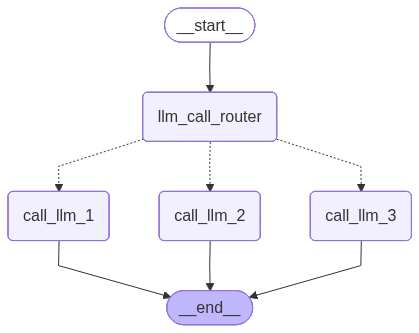

In [52]:
router_workflow

In [53]:
router_workflow.invoke({"input": "고양이에 대한 농담 하나 해줘"})

{'input': '고양이에 대한 농담 하나 해줘',
 'decision': 'joke',
 'output': '[코미디언 노드에서 작성됨]\n고양이를 키우시는 분들이라면 무릎을 탁 칠만한 농담 하나 해드릴게요!\n\n***\n\n어느 날, 주인과 고양이가 대화를 나누고 있었습니다.\n\n**주인:** "고양아, 넌 참 좋겠다. 내가 밥 주고, 잠자리 제공해주고, 화장실도 치워주고, 예쁘다 예쁘다 해주잖아. 넌 하는 게 없는데 말이야."\n\n그러자 고양이가 하품을 하며 주인에게 대답했습니다.\n\n**고양이:** "무슨 소리야? 내가 매일 집안 구석구석을 돌아다니며 **\'투명한 고스트\'**들을 쫓아내고 있잖아. 내가 없으면 너희 가족은 지금쯤 유령들한테 다 당했을걸?"\n\n**주인:** "그럼 그 대가로 내가 밥을 주는 거라는 거야?"\n\n**고양이:** "아니, **내가 널 키우기로 마음먹었으니까 밥을 챙겨주는 거지.** 너도 참, 아직도 서열 파악이 안 되냐?"\n\n***\n\n역시 고양이는 \'집사\'가 아니라 \'집사\'를 둔 주인이었네요! 😸'}

In [54]:
print(router_workflow.invoke({"input": "고양이에 대한 시 하나 써줘"})['output'])

[시인 노드에서 작성됨]
고양이에 대한 시 한 편과 하이쿠 한 편을 각각 써 드립니다.

***

### [시] 발바닥의 계절

어둠을 핥아 올리는
말랑한 분홍색 발바닥
소리 없이 거실을 가로지르면
오후의 햇살이 꼬리에 엉겨 붙는다

가장 높은 곳에서 
세상의 낮잠을 내려다보는
고독한 여행자여
너의 눈동자 속에는
길들여지지 않는 별들이 산다

***

### [하이쿠]

**햇살 머금고**
**낮게 울리는 기척**
**나른한 오후**


In [55]:
print(router_workflow.invoke({"input": "고양이에 대한 동화 하나 써줘"})['output'])

[동화 작가 노드에서 작성됨]
고양이에 대한 짧고 따뜻한 동화 한 편을 들려드릴게요.

***

### 제목: 달빛을 모으는 고양이, 루나

옛날 아주 먼 옛날, 커다란 밤나무 위에 ‘루나’라는 이름의 작은 고양이가 살고 있었어요. 루나는 세상의 다른 고양이들과 조금 달랐어요. 낮에는 세상모르고 쿨쿨 잠만 잤지만, 밤이 되면 지붕 위로 올라가 꼬리를 살랑거리며 무언가를 기다렸거든요.

“오늘 밤도 달빛이 아주 맛있겠는걸!”

루나가 꼬리를 하늘로 높이 치켜세우면, 밤하늘에서 은은한 달빛이 가루처럼 쏟아져 내려와 루나의 털 속으로 쏙쏙 스며들었어요. 루나는 그렇게 모은 달빛을 매일 밤 바구니에 담아두었지요.

그러던 어느 날, 마을에 큰 걱정거리가 생겼어요. 며칠째 구름이 잔뜩 끼어 햇님도 달님도 보이지 않는 어두컴컴한 날들이 계속된 거예요. 아이들은 밤이 무섭다며 울먹였고, 길을 잃는 사람들도 많아졌죠.

루나는 결심했어요. 
“내가 모아둔 달빛이 빛을 발할 때가 왔어.”

루나는 밤나무 꼭대기에 올라가 그동안 차곡차곡 모아두었던 달빛 바구니를 활짝 열었어요. 그러자 몽글몽글한 달빛들이 공처럼 튀어 올라 마을 전체를 환하게 비추기 시작했어요. 마치 수천 개의 별이 마을로 내려온 것 같았죠.

사람들은 깜짝 놀라 창문을 열고 밖을 내다보았어요. 밤하늘엔 달이 없었지만, 마을은 루나가 나눠준 따뜻한 달빛 덕분에 낮보다 더 포근하고 아름답게 빛났답니다.

그날 이후, 마을 사람들은 밤마다 지붕 위를 바라보게 되었어요. 어둠 속에서 은은하게 빛나는 루나의 눈동자를 보며, 사람들은 안심하고 단잠에 들 수 있었죠.

지금도 밤하늘에 유난히 밝은 별이 보인다면, 그건 아마 루나가 당신을 위해 살짝 달빛을 뿌려주고 있는 것일지도 몰라요.

***

오늘 밤, 당신의 꿈속에도 루나의 달빛이 찾아가길 바랄게요.
